# CNN + GloVe (Colab) — Training Size Sweep (Exp 12)

Iterative benchmark sweep over training-set sizes using the single best CNN+GloVe configuration
identified in the `01_cnn_glove` notebook.

**Best config carried over from `01_cnn_glove` (lossselect / ALL ON run):**
- `USE_POS_WEIGHT=True`, `USE_GLOVE=True` (GloVe 6B 100d, trainable)
- `MAX_LEN=256`, `BATCH_SIZE=64`, `LR=1e-3`, `MAX_VOCAB=50000`, `MIN_FREQ=2`
- Preprocessing ALL ON: `use_iterative_stratify=True`, `rebalance_train=True`,
  `clean_to_toxic_ratio=3.0`, rare-label oversampling x2 (max 3 copies)
- Early stopping on min val loss: `PATIENCE=2`, `MIN_DELTA=0.005`, `MAX_EPOCHS=20`
- TextCNN: kernel_sizes=(3,4,5), num_filters=100, dropout=0.5

**Goal:** Measure CNN+GloVe data-efficiency and training speed vs. DistilBERT, BERT, and
BiLSTM+Attention across iterative 10k training-size steps on a Google Colab L4 GPU.


In [5]:
!pip -q install torch pandas numpy matplotlib scikit-learn seaborn iterative-stratification


In [6]:
from pathlib import Path
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

# ===== CHANGE THIS to your repo folder in Drive =====
PROJECT_ROOT = Path('/content/drive/MyDrive/school/2026Spring/cmpe258/CMPE258-Distil')

if not IN_COLAB:
    _cwd = Path.cwd().resolve()
    for _p in [_cwd] + list(_cwd.parents)[:4]:
        if (_p / 'preprocessing' / 'text_preprocessing.py').exists():
            PROJECT_ROOT = _p
            break

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f'PROJECT_ROOT not found: {PROJECT_ROOT}\n'
        'Upload/clone your repo to Drive at that path first.'
    )

NOTEBOOKS_DIR = PROJECT_ROOT / 'notebooks'
ARTIFACT_DIR  = NOTEBOOKS_DIR / 'cnn_glove_sweep'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(NOTEBOOKS_DIR))

print('PROJECT_ROOT:', PROJECT_ROOT)
print('ARTIFACT_DIR:', ARTIFACT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/drive/MyDrive/school/2026Spring/cmpe258/CMPE258-Distil
ARTIFACT_DIR: /content/drive/MyDrive/school/2026Spring/cmpe258/CMPE258-Distil/notebooks/cnn_glove_sweep


In [7]:
import urllib.request, zipfile, pathlib

data_dir = PROJECT_ROOT / 'data'
data_dir.mkdir(exist_ok=True)

glove_zip = data_dir / 'glove.6B.zip'
urllib.request.urlretrieve(
    'https://nlp.stanford.edu/data/glove.6B.zip',
    glove_zip
)
with zipfile.ZipFile(glove_zip) as z:
    z.extract('glove.6B.100d.txt', data_dir)
glove_zip.unlink()
print('Done:', data_dir / 'glove.6B.100d.txt')

Done: /content/drive/MyDrive/school/2026Spring/cmpe258/CMPE258-Distil/data/glove.6B.100d.txt


In [8]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, f1_score

from preprocessing.text_preprocessing import LABEL_COLUMNS, preprocess_for_cnn
from metrics_helpers import multilabel_evaluation_report, torch_parameter_count

RARE_LABELS   = ['severe_toxic', 'threat', 'identity_hate']
COMMON_LABELS = ['toxic', 'obscene', 'insult']
LABEL_COLORS  = {
    'toxic':         '#e74c3c',
    'severe_toxic':  '#c0392b',
    'obscene':       '#e67e22',
    'threat':        '#8e44ad',
    'insult':        '#2980b9',
    'identity_hate': '#16a085',
}


# ── Helpers ────────────────────────────────────────────────────────────────────────────
def pick_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


def build_glove_weight_matrix(vocab, glove_path, dim, rng_seed=42):
    rng    = np.random.default_rng(rng_seed)
    matrix = rng.normal(0.0, 0.05, (len(vocab), dim)).astype(np.float32)
    pad_idx = vocab.get('<pad>', 0)
    matrix[pad_idx] = 0.0
    matched = 0
    with open(glove_path, 'r', encoding='utf-8') as fh:
        for line in fh:
            parts = line.strip().split()
            if len(parts) != dim + 1:
                continue
            idx = vocab.get(parts[0])
            if idx is None:
                continue
            matrix[idx] = np.asarray(parts[1:], dtype=np.float32)
            matched += 1
    return matrix, matched


def tune_per_label_thresholds(y_true, y_prob, labels, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)
    y_int = np.asarray(y_true, dtype=np.int64)
    best_thresholds, rows = {}, []
    for j, label in enumerate(labels):
        y_t, y_p = y_int[:, j], y_prob[:, j]
        best_f, best_t = -1.0, 0.5
        for t in grid:
            f = f1_score(y_t, (y_p >= t).astype(np.int64), zero_division=0)
            if f > best_f + 1e-12 or (abs(f - best_f) <= 1e-12 and abs(float(t) - 0.5) < abs(best_t - 0.5)):
                best_f, best_t = float(f), float(t)
        best_thresholds[label] = best_t
        rows.append({'label': label, 'best_threshold': round(best_t, 4), 'best_f1_on_val': round(best_f, 6)})
    return best_thresholds, pd.DataFrame(rows)


def apply_thresholds(y_prob, labels, thresholds):
    out = np.zeros((y_prob.shape[0], len(labels)), dtype=np.int64)
    for j, label in enumerate(labels):
        out[:, j] = (y_prob[:, j] >= thresholds[label]).astype(np.int64)
    return out


def make_confusion_artifacts(y_true, y_pred, labels):
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)
    rows = []
    for j, label in enumerate(labels):
        tn, fp, fn, tp = confusion_matrix(y_true[:, j], y_pred[:, j], labels=[0, 1]).ravel()
        rows.append({'label': label, 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)})
    agg_tn, agg_fp, agg_fn, agg_tp = confusion_matrix(y_true.ravel(), y_pred.ravel(), labels=[0, 1]).ravel()
    return (
        pd.DataFrame(rows),
        pd.DataFrame([{'tn': int(agg_tn), 'fp': int(agg_fp), 'fn': int(agg_fn), 'tp': int(agg_tp)}]),
    )


def predict_probs(model, X_np, device, batch_size=512):
    model.eval()
    probs = []
    x_t = torch.tensor(X_np, dtype=torch.long)
    with torch.no_grad():
        for i in range(0, len(x_t), batch_size):
            logits = model(x_t[i:i+batch_size].to(device))
            probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(probs, axis=0)


# ── Model ─────────────────────────────────────────────────────────────────────────────────────
class TextCNN(nn.Module):
    # Kim-style multi-channel CNN over embeddings
    def __init__(self, vocab_size, embed_dim, num_labels, padding_idx=0,
                 kernel_sizes=(3, 4, 5), num_filters=100):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.convs     = nn.ModuleList([nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes])
        self.dropout   = nn.Dropout(0.5)
        self.fc        = nn.Linear(num_filters * len(kernel_sizes), num_labels)

    def forward(self, x):
        e = self.embedding(x).transpose(1, 2)
        pools = [torch.relu(conv(e)).max(dim=2).values for conv in self.convs]
        return self.fc(self.dropout(torch.cat(pools, dim=1)))


In [9]:
DEVICE = pick_device()
if DEVICE.type == 'cuda':
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

torch.manual_seed(42)
np.random.seed(42)

# ── Best config from 01_cnn_glove (lossselect / ALL ON run) ──────────────────────
# tokenization
MAX_LEN   = 256
MAX_VOCAB = 50_000
MIN_FREQ  = 2

# GloVe
GLOVE_DIM       = 100
GLOVE_PATH      = PROJECT_ROOT / 'data' / 'glove.6B.100d.txt'
GLOVE_TRAINABLE = True

# training
BATCH_SIZE = 64
MAX_EPOCHS = 20
LR         = 1e-3

# early stopping on val loss (matching 01_cnn_glove lossselect setup)
ES_PATIENCE  = 2
ES_MIN_DELTA = 0.005

# preprocessing — ALL ON
VALIDATION_FRACTION    = 0.1
RANDOM_STATE           = 42
USE_ITERATIVE_STRATIFY = True
REBALANCE_TRAIN        = True
CLEAN_TO_TOXIC_RATIO   = 3.0
REBALANCE_RARE_LABELS  = ('severe_toxic', 'threat', 'identity_hate')
RARE_OVERSAMPLE_FACTOR = 2.0
MAX_COPIES_PER_ROW     = 3
REBALANCE_RANDOM_STATE = 42
MAX_VAL_SAMPLES        = None

# sweep
SIZE_STEP      = 10_000
SKIP_COMPLETED = True   # resume safely after Colab disconnect

TORCH_SEED = 42
NUMPY_SEED = 42

print(f'Device:       {DEVICE}')
print(f'MAX_LEN:      {MAX_LEN}  |  MAX_VOCAB: {MAX_VOCAB}  |  MIN_FREQ: {MIN_FREQ}')
print(f'GLOVE:        {GLOVE_PATH.name}  dim={GLOVE_DIM}  trainable={GLOVE_TRAINABLE}')
print(f'LR:           {LR}  |  BATCH_SIZE: {BATCH_SIZE}  |  MAX_EPOCHS: {MAX_EPOCHS}')
print(f'Early stop:   patience={ES_PATIENCE}, min_delta={ES_MIN_DELTA}  (criterion: min val loss)')
print(f'Preprocessing: iterative_stratify={USE_ITERATIVE_STRATIFY}, rebalance={REBALANCE_TRAIN}, ratio={CLEAN_TO_TOXIC_RATIO}')
print(f'Skip done:    {SKIP_COMPLETED}')

if not GLOVE_PATH.is_file():
    raise FileNotFoundError(f'GloVe file not found: {GLOVE_PATH}. Place glove.6B.100d.txt in data/.')


Device:       cuda
MAX_LEN:      256  |  MAX_VOCAB: 50000  |  MIN_FREQ: 2
GLOVE:        glove.6B.100d.txt  dim=100  trainable=True
LR:           0.001  |  BATCH_SIZE: 64  |  MAX_EPOCHS: 20
Early stop:   patience=2, min_delta=0.005  (criterion: min val loss)
Preprocessing: iterative_stratify=True, rebalance=True, ratio=3.0
Skip done:    True


In [10]:
print('Probing full dataset size...')
_probe = preprocess_for_cnn(
    max_len=MAX_LEN,
    validation_fraction=VALIDATION_FRACTION,
    random_state=RANDOM_STATE,
    min_freq=MIN_FREQ,
    max_vocab=MAX_VOCAB,
    max_train_samples=None,
    max_val_samples=MAX_VAL_SAMPLES,
    use_iterative_stratify=USE_ITERATIVE_STRATIFY,
    rebalance_train=REBALANCE_TRAIN,
    clean_to_toxic_ratio=CLEAN_TO_TOXIC_RATIO,
    rare_labels=REBALANCE_RARE_LABELS,
    rare_oversample_factor=RARE_OVERSAMPLE_FACTOR,
    max_copies_per_row=MAX_COPIES_PER_ROW,
    rebalance_random_state=REBALANCE_RANDOM_STATE,
    print_diagnostics=True,
)
full_train_count = int(_probe.X_train.shape[0])
print(f'Full train rows: {full_train_count}  |  Val rows: {_probe.X_val.shape[0]}')

# Report GloVe coverage on full vocab
_full_glove, _full_matched = build_glove_weight_matrix(_probe.vocab, GLOVE_PATH, GLOVE_DIM)
print(f'Full vocab GloVe coverage: {_full_matched}/{len(_probe.vocab)} ({100*_full_matched/len(_probe.vocab):.1f}%)')
del _probe, _full_glove

if full_train_count <= SIZE_STEP:
    train_sizes = [full_train_count]
else:
    train_sizes = list(range(SIZE_STEP, full_train_count + 1, SIZE_STEP))
    if train_sizes[-1] != full_train_count:
        train_sizes.append(full_train_count)

run_specs = [
    {'train_size': int(s), 'train_fraction': float(s) / float(full_train_count), 'max_train_samples': int(s)}
    for s in train_sizes
]
print(f'Sweep sizes: {train_sizes[:4]} ... {train_sizes[-1]}  (n={len(train_sizes)})')


Probing full dataset size...
[preprocess] train_before: rows=143613, clean=129012, toxic=13765, severe_toxic=1435, obscene=7604, threat=430, insult=7089, identity_hate=1264
[preprocess] train_after: rows=61088, clean=43803, toxic=16331, severe_toxic=2870, obscene=9759, threat=860, insult=9234, identity_hate=2528
[preprocess] val_unchanged: rows=15958, clean=14334, toxic=1529, severe_toxic=160, obscene=845, threat=48, insult=788, identity_hate=141
Full train rows: 61088  |  Val rows: 15958
Full vocab GloVe coverage: 17251/50000 (34.5%)
Sweep sizes: [10000, 20000, 30000, 40000] ... 61088  (n=7)


In [11]:
summary_rows         = []
per_label_frames     = []
threshold_frames     = []
conf_pl_base_frames  = []
conf_pl_tuned_frames = []
conf_agg_base_rows   = []
conf_agg_tuned_rows  = []

torch.manual_seed(TORCH_SEED)
np.random.seed(NUMPY_SEED)

for idx, spec in enumerate(run_specs, start=1):
    run_id = f"train_size_{spec['train_size']}"

    row_file            = ARTIFACT_DIR / f'summary_{run_id}.csv'
    per_label_file      = ARTIFACT_DIR / f'per_label_{run_id}.csv'
    thresholds_file     = ARTIFACT_DIR / f'thresholds_{run_id}.csv'
    conf_pl_base_file   = ARTIFACT_DIR / f'confusion_per_label_baseline_{run_id}.csv'
    conf_pl_tuned_file  = ARTIFACT_DIR / f'confusion_per_label_tuned_{run_id}.csv'
    conf_agg_base_file  = ARTIFACT_DIR / f'confusion_aggregate_baseline_{run_id}.csv'
    conf_agg_tuned_file = ARTIFACT_DIR / f'confusion_aggregate_tuned_{run_id}.csv'

    files_exist = all([
        row_file.exists(), per_label_file.exists(), thresholds_file.exists(),
        conf_pl_base_file.exists(), conf_pl_tuned_file.exists(),
        conf_agg_base_file.exists(), conf_agg_tuned_file.exists(),
    ])

    if SKIP_COMPLETED and files_exist:
        try:
            print(f'[{idx}/{len(run_specs)}] {run_id}: skipping (already saved)')
            summary_rows.append(pd.read_csv(row_file).iloc[0].to_dict())
            per_label_frames.append(pd.read_csv(per_label_file))
            threshold_frames.append(pd.read_csv(thresholds_file))
            conf_pl_base_frames.append(pd.read_csv(conf_pl_base_file))
            conf_pl_tuned_frames.append(pd.read_csv(conf_pl_tuned_file))
            conf_agg_base_rows.append(pd.read_csv(conf_agg_base_file).iloc[0].to_dict())
            conf_agg_tuned_rows.append(pd.read_csv(conf_agg_tuned_file).iloc[0].to_dict())
            continue
        except OSError as e:
            print(f'[{idx}/{len(run_specs)}] {run_id}: read failed ({e}); rerunning.')

    print(
        f"[{idx}/{len(run_specs)}] {run_id}: running "
        f"(max_train={spec['max_train_samples']}, frac={spec['train_fraction']:.4f})"
    )

    # ── Data ──────────────────────────────────────────────────────────────────
    run_data = preprocess_for_cnn(
        max_len=MAX_LEN,
        validation_fraction=VALIDATION_FRACTION,
        random_state=RANDOM_STATE,
        min_freq=MIN_FREQ,
        max_vocab=MAX_VOCAB,
        max_train_samples=spec['max_train_samples'],
        max_val_samples=MAX_VAL_SAMPLES,
        use_iterative_stratify=USE_ITERATIVE_STRATIFY,
        rebalance_train=REBALANCE_TRAIN,
        clean_to_toxic_ratio=CLEAN_TO_TOXIC_RATIO,
        rare_labels=REBALANCE_RARE_LABELS,
        rare_oversample_factor=RARE_OVERSAMPLE_FACTOR,
        max_copies_per_row=MAX_COPIES_PER_ROW,
        rebalance_random_state=REBALANCE_RANDOM_STATE,
        print_diagnostics=False,
    )
    X_train    = run_data.X_train
    y_train_np = run_data.y_train.astype(np.float32)
    X_val      = run_data.X_val
    y_val_np   = run_data.y_val.astype(np.int64)
    vocab_size = len(run_data.vocab)

    # GloVe for this vocab
    glove_matrix, glove_matched = build_glove_weight_matrix(run_data.vocab, GLOVE_PATH, GLOVE_DIM)

    train_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_train,    dtype=torch.long),
            torch.tensor(y_train_np, dtype=torch.float32),
        ),
        batch_size=BATCH_SIZE, shuffle=True,
    )
    val_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_val,    dtype=torch.long),
            torch.tensor(y_val_np, dtype=torch.float32),
        ),
        batch_size=BATCH_SIZE, shuffle=False,
    )

    # ── Model ─────────────────────────────────────────────────────────────────
    model = TextCNN(vocab_size, GLOVE_DIM, len(LABEL_COLUMNS)).to(DEVICE)
    with torch.no_grad():
        model.embedding.weight.copy_(torch.tensor(glove_matrix, dtype=torch.float32, device=DEVICE))
    model.embedding.weight.requires_grad = GLOVE_TRAINABLE
    num_params = torch_parameter_count(model)

    _pos        = y_train_np.sum(axis=0).clip(min=1)
    _neg        = len(y_train_np) - _pos
    pos_weights = torch.tensor((_neg / _pos).astype(np.float32), device=DEVICE)
    loss_fn     = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
    optimizer   = torch.optim.Adam(model.parameters(), lr=LR)

    # ── Training loop (val-loss early stopping) ────────────────────────────────
    best_val_loss   = float('inf')
    best_epoch      = 0
    best_state_cpu  = None
    patience_left   = ES_PATIENCE
    epochs_ran      = 0
    early_stopped   = False
    train_time_s    = 0.0
    train_loss_last = float('nan')

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        t0 = time.perf_counter()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb.to(DEVICE)), yb.to(DEVICE))
            loss.backward()
            optimizer.step()
            epoch_loss += float(loss.item())
            n_batches  += 1
        train_time_s   += time.perf_counter() - t0
        train_loss_last = epoch_loss / max(n_batches, 1)

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for xv, yv in val_loader:
                v_loss += float(loss_fn(model(xv.to(DEVICE)), yv.to(DEVICE)).item())
        val_loss_epoch = v_loss / max(len(val_loader), 1)
        epochs_ran = epoch

        improved = (epoch == 1) or (val_loss_epoch < best_val_loss - ES_MIN_DELTA)
        if improved:
            best_val_loss  = val_loss_epoch
            best_epoch     = epoch
            patience_left  = ES_PATIENCE
            best_state_cpu = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_left -= 1
            if patience_left <= 0:
                early_stopped = True
                print(f'  early stop at epoch {epoch}')
                break

        star = ' *' if improved else ''
        print(
            f'  ep {epoch:02d} | train={train_loss_last:.4f} | val={val_loss_epoch:.4f} | '
            f'pat={patience_left}{star}'
        )

    if best_state_cpu:
        model.load_state_dict(best_state_cpu)

    # ── Final inference on best checkpoint ────────────────────────────────────
    t_inf = time.perf_counter()
    y_prob = predict_probs(model, X_val, DEVICE)
    inference_time_s = time.perf_counter() - t_inf

    # Metrics @ 0.5
    y_pred_base = (y_prob >= 0.5).astype(np.int64)
    _, base_summary = multilabel_evaluation_report(y_val_np, y_pred_base, y_prob, LABEL_COLUMNS)

    # Threshold tuning
    best_thr, thresholds_df = tune_per_label_thresholds(y_val_np, y_prob, LABEL_COLUMNS)
    y_pred_tuned = apply_thresholds(y_prob, LABEL_COLUMNS, best_thr)
    per_label_df, tuned_summary = multilabel_evaluation_report(y_val_np, y_pred_tuned, y_prob, LABEL_COLUMNS)

    conf_pl_base_df,  conf_agg_base_df  = make_confusion_artifacts(y_val_np, y_pred_base,  LABEL_COLUMNS)
    conf_pl_tuned_df, conf_agg_tuned_df = make_confusion_artifacts(y_val_np, y_pred_tuned, LABEL_COLUMNS)

    for df in [per_label_df, thresholds_df, conf_pl_base_df, conf_pl_tuned_df,
               conf_agg_base_df, conf_agg_tuned_df]:
        df.insert(0, 'train_size',        spec['train_size'])
        df.insert(1, 'train_fraction',    spec['train_fraction'])
        df.insert(2, 'max_train_samples', spec['max_train_samples'])

    row = {
        'run_id':                run_id,
        'train_size':            spec['train_size'],
        'train_fraction':        spec['train_fraction'],
        'max_train_samples':     spec['max_train_samples'],
        'actual_train_samples':  int(X_train.shape[0]),
        'actual_val_samples':    int(X_val.shape[0]),
        'vocab_size':            vocab_size,
        'glove_coverage_pct':    round(100.0 * glove_matched / vocab_size, 2),
        'validation_fraction':   VALIDATION_FRACTION,
        'random_state':          RANDOM_STATE,
        'use_iterative_stratify': USE_ITERATIVE_STRATIFY,
        'rebalance_train':       REBALANCE_TRAIN,
        'max_len':               MAX_LEN,
        'max_vocab':             MAX_VOCAB,
        'min_freq':              MIN_FREQ,
        'glove_dim':             GLOVE_DIM,
        'glove_trainable':       GLOVE_TRAINABLE,
        'batch_size':            BATCH_SIZE,
        'max_epochs':            MAX_EPOCHS,
        'epochs_ran':            epochs_ran,
        'best_epoch':            best_epoch,
        'early_stopped':         early_stopped,
        'learning_rate':         LR,
        'es_patience':           ES_PATIENCE,
        'es_min_delta':          ES_MIN_DELTA,
        'loss_type':             'BCEWithLogitsLoss+pos_weight',
        'num_params':            num_params,
        'train_time_s':          round(train_time_s, 2),
        'inference_time_s':      round(inference_time_s, 4),
        'train_loss':            round(train_loss_last, 6),
        'best_val_loss':         round(best_val_loss, 6),
        'baseline_micro_f1':     base_summary['f1_micro'],
        'baseline_macro_f1':     base_summary['f1_macro'],
        'baseline_samples_f1':   float(f1_score(y_val_np, y_pred_base,  average='samples', zero_division=0)),
        'tuned_micro_f1':        tuned_summary['f1_micro'],
        'tuned_macro_f1':        tuned_summary['f1_macro'],
        'tuned_samples_f1':      float(f1_score(y_val_np, y_pred_tuned, average='samples', zero_division=0)),
    }

    pd.DataFrame([row]).to_csv(row_file,            index=False)
    per_label_df.to_csv(per_label_file,              index=False)
    thresholds_df.to_csv(thresholds_file,            index=False)
    conf_pl_base_df.to_csv(conf_pl_base_file,        index=False)
    conf_pl_tuned_df.to_csv(conf_pl_tuned_file,      index=False)
    conf_agg_base_df.to_csv(conf_agg_base_file,      index=False)
    conf_agg_tuned_df.to_csv(conf_agg_tuned_file,    index=False)

    summary_rows.append(row)
    per_label_frames.append(per_label_df)
    threshold_frames.append(thresholds_df)
    conf_pl_base_frames.append(conf_pl_base_df)
    conf_pl_tuned_frames.append(conf_pl_tuned_df)
    conf_agg_base_rows.append(conf_agg_base_df.iloc[0].to_dict())
    conf_agg_tuned_rows.append(conf_agg_tuned_df.iloc[0].to_dict())

    print(
        f"  done | n={int(X_train.shape[0])} | vocab={vocab_size} | glove={row['glove_coverage_pct']:.1f}% | "
        f"macro={tuned_summary['f1_macro']:.4f} | micro={tuned_summary['f1_micro']:.4f} | "
        f"time={train_time_s:.0f}s"
    )

print('Sweep complete.')


[1/7] train_size_10000: running (max_train=10000, frac=0.1637)
  ep 01 | train=0.9006 | val=0.4017 | pat=2 *
  ep 02 | train=0.6086 | val=0.3105 | pat=2 *
  ep 03 | train=0.4960 | val=0.2746 | pat=2 *
  ep 04 | train=0.4087 | val=0.2482 | pat=2 *
  ep 05 | train=0.3441 | val=0.2347 | pat=2 *
  ep 06 | train=0.2905 | val=0.2369 | pat=1
  early stop at epoch 7
  done | n=10000 | vocab=24700 | glove=39.3% | macro=0.5333 | micro=0.6505 | time=6s
[2/7] train_size_20000: running (max_train=20000, frac=0.3274)
  ep 01 | train=0.7730 | val=0.2931 | pat=2 *
  ep 02 | train=0.5150 | val=0.2677 | pat=2 *
  ep 03 | train=0.4095 | val=0.2354 | pat=2 *
  ep 04 | train=0.3262 | val=0.2353 | pat=1
  early stop at epoch 5
  done | n=20000 | vocab=41695 | glove=34.3% | macro=0.5490 | micro=0.6667 | time=7s
[3/7] train_size_30000: running (max_train=30000, frac=0.4911)
  ep 01 | train=0.7096 | val=0.3013 | pat=2 *
  ep 02 | train=0.4686 | val=0.2469 | pat=2 *
  ep 03 | train=0.3622 | val=0.2311 | pat=2 *

In [12]:
summary_df     = pd.DataFrame(summary_rows).sort_values('train_size').reset_index(drop=True)
per_label_all  = pd.concat(per_label_frames,     ignore_index=True) if per_label_frames  else pd.DataFrame()
thresholds_all = pd.concat(threshold_frames,     ignore_index=True) if threshold_frames  else pd.DataFrame()
conf_pl_base_all  = pd.concat(conf_pl_base_frames,  ignore_index=True) if conf_pl_base_frames  else pd.DataFrame()
conf_pl_tuned_all = pd.concat(conf_pl_tuned_frames, ignore_index=True) if conf_pl_tuned_frames else pd.DataFrame()
conf_agg_base_all  = pd.DataFrame(conf_agg_base_rows)
conf_agg_tuned_all = pd.DataFrame(conf_agg_tuned_rows)

summary_df.to_csv(ARTIFACT_DIR        / 'cnn_glove_sweep_summary.csv',                         index=False)
per_label_all.to_csv(ARTIFACT_DIR     / 'cnn_glove_sweep_per_label.csv',                       index=False)
thresholds_all.to_csv(ARTIFACT_DIR    / 'cnn_glove_sweep_thresholds.csv',                      index=False)
conf_pl_base_all.to_csv(ARTIFACT_DIR  / 'cnn_glove_sweep_confusion_per_label_baseline.csv',    index=False)
conf_pl_tuned_all.to_csv(ARTIFACT_DIR / 'cnn_glove_sweep_confusion_per_label_tuned.csv',       index=False)
conf_agg_base_all.to_csv(ARTIFACT_DIR / 'cnn_glove_sweep_confusion_aggregate_baseline.csv',    index=False)
conf_agg_tuned_all.to_csv(ARTIFACT_DIR/ 'cnn_glove_sweep_confusion_aggregate_tuned.csv',       index=False)

print(f'Saved to: {ARTIFACT_DIR}  ({len(summary_df)} runs)')
summary_df[[
    'train_size', 'actual_train_samples', 'vocab_size', 'glove_coverage_pct',
    'epochs_ran', 'best_epoch', 'early_stopped',
    'baseline_micro_f1', 'baseline_macro_f1',
    'tuned_micro_f1', 'tuned_macro_f1',
    'train_time_s', 'inference_time_s',
]]


Saved to: /content/drive/MyDrive/school/2026Spring/cmpe258/CMPE258-Distil/notebooks/cnn_glove_sweep  (7 runs)


,train_size,actual_train_samples,vocab_size,glove_coverage_pct,epochs_ran,best_epoch,early_stopped,baseline_micro_f1,baseline_macro_f1,tuned_micro_f1,tuned_macro_f1,train_time_s,inference_time_s
0,10000,10000,24700,39.32,7,5,True,0.560384,0.438679,0.650538,0.533322,5.85,0.2671
1,20000,20000,41695,34.26,5,3,True,0.531201,0.424880,0.666667,0.549035,6.62,0.2558
2,30000,30000,50000,32.77,5,3,True,0.564185,0.444029,0.685914,0.565954,10.43,0.2559
3,40000,40000,50000,33.48,5,3,True,0.644770,0.510301,0.697456,0.576634,13.63,0.2552
4,50000,50000,50000,34.06,4,2,True,0.562722,0.440264,0.691460,0.573972,13.84,0.2592
5,60000,60000,50000,34.50,4,2,True,0.611363,0.485706,0.706171,0.579713,16.55,0.2609
6,61088,61088,50000,34.50,4,2,True,0.585096,0.462898,0.695702,0.575577,16.89,0.2580


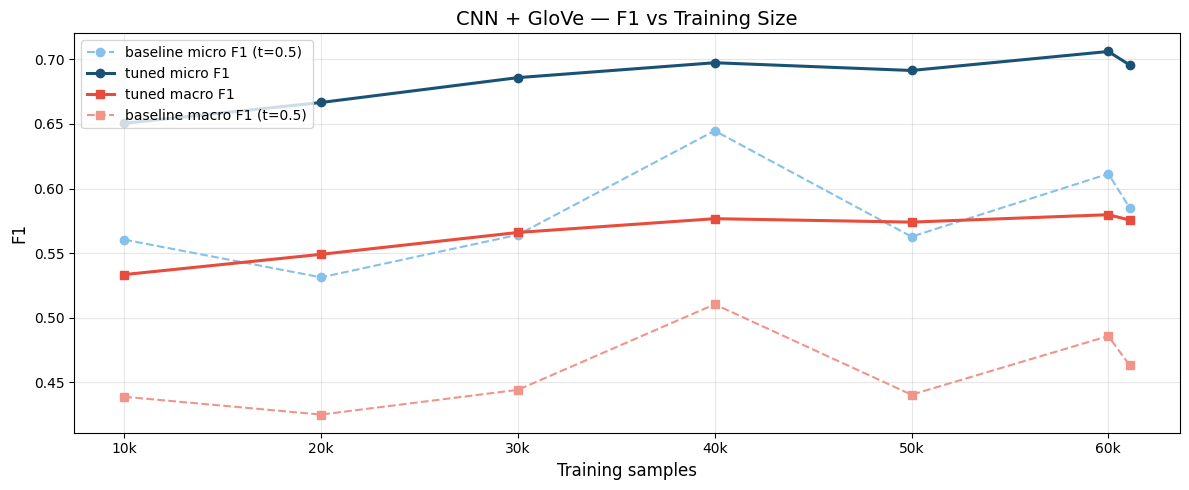

In [13]:
# Graph 1: F1 vs training size
plot_df = summary_df.sort_values('train_size').copy()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(plot_df['train_size'], plot_df['baseline_micro_f1'],
        marker='o', linestyle='--', color='#85c1e9', linewidth=1.5, label='baseline micro F1 (t=0.5)')
ax.plot(plot_df['train_size'], plot_df['tuned_micro_f1'],
        marker='o', color='#1a5276', linewidth=2.2, label='tuned micro F1')
ax.plot(plot_df['train_size'], plot_df['tuned_macro_f1'],
        marker='s', color='#e74c3c', linewidth=2.2, label='tuned macro F1')
ax.plot(plot_df['train_size'], plot_df['baseline_macro_f1'],
        marker='s', linestyle='--', color='#f1948a', linewidth=1.5, label='baseline macro F1 (t=0.5)')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_xlabel('Training samples', fontsize=12)
ax.set_ylabel('F1', fontsize=12)
ax.set_title('CNN + GloVe — F1 vs Training Size', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'graph1_f1_vs_size.png', dpi=150, bbox_inches='tight')
plt.show()


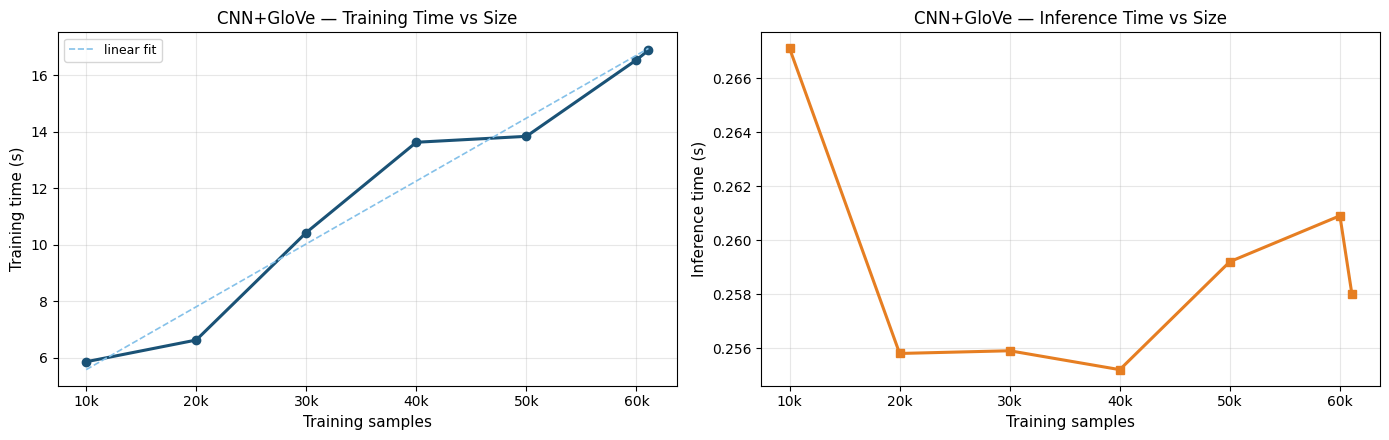

In [14]:
# Graph 2: Training and inference time vs training size
plot_df = summary_df.sort_values('train_size').copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.plot(plot_df['train_size'], plot_df['train_time_s'],
         marker='o', color='#1a5276', linewidth=2.2)
if len(plot_df) >= 3:
    z = np.polyfit(plot_df['train_size'], plot_df['train_time_s'], 1)
    ax1.plot(plot_df['train_size'], np.poly1d(z)(plot_df['train_size']),
             linestyle='--', color='#85c1e9', linewidth=1.2, label='linear fit')
    ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax1.set_xlabel('Training samples', fontsize=11)
ax1.set_ylabel('Training time (s)', fontsize=11)
ax1.set_title('CNN+GloVe — Training Time vs Size', fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.plot(plot_df['train_size'], plot_df['inference_time_s'],
         marker='s', color='#e67e22', linewidth=2.2)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax2.set_xlabel('Training samples', fontsize=11)
ax2.set_ylabel('Inference time (s)', fontsize=11)
ax2.set_title('CNN+GloVe — Inference Time vs Size', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'graph2_time_vs_size.png', dpi=150, bbox_inches='tight')
plt.show()


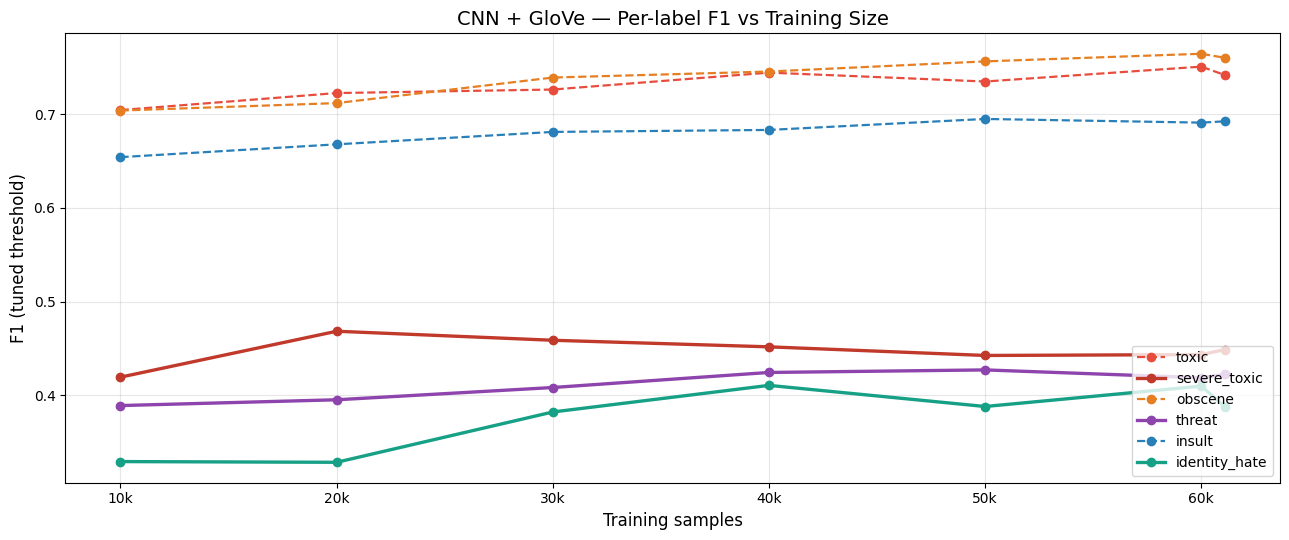

In [15]:
# Graph 3: Per-label F1 vs training size (tuned threshold)
if not per_label_all.empty:
    fig, ax = plt.subplots(figsize=(13, 5.5))
    for label in LABEL_COLUMNS:
        ldf = per_label_all[per_label_all['label'] == label].sort_values('train_size')
        lw  = 2.4 if label in RARE_LABELS else 1.6
        ls  = '-' if label in RARE_LABELS else '--'
        ax.plot(ldf['train_size'], ldf['f1'],
                marker='o', linewidth=lw, linestyle=ls,
                color=LABEL_COLORS[label], label=label)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    ax.set_xlabel('Training samples', fontsize=12)
    ax.set_ylabel('F1 (tuned threshold)', fontsize=12)
    ax.set_title('CNN + GloVe — Per-label F1 vs Training Size', fontsize=14)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / 'graph3_per_label_f1_vs_size.png', dpi=150, bbox_inches='tight')
    plt.show()


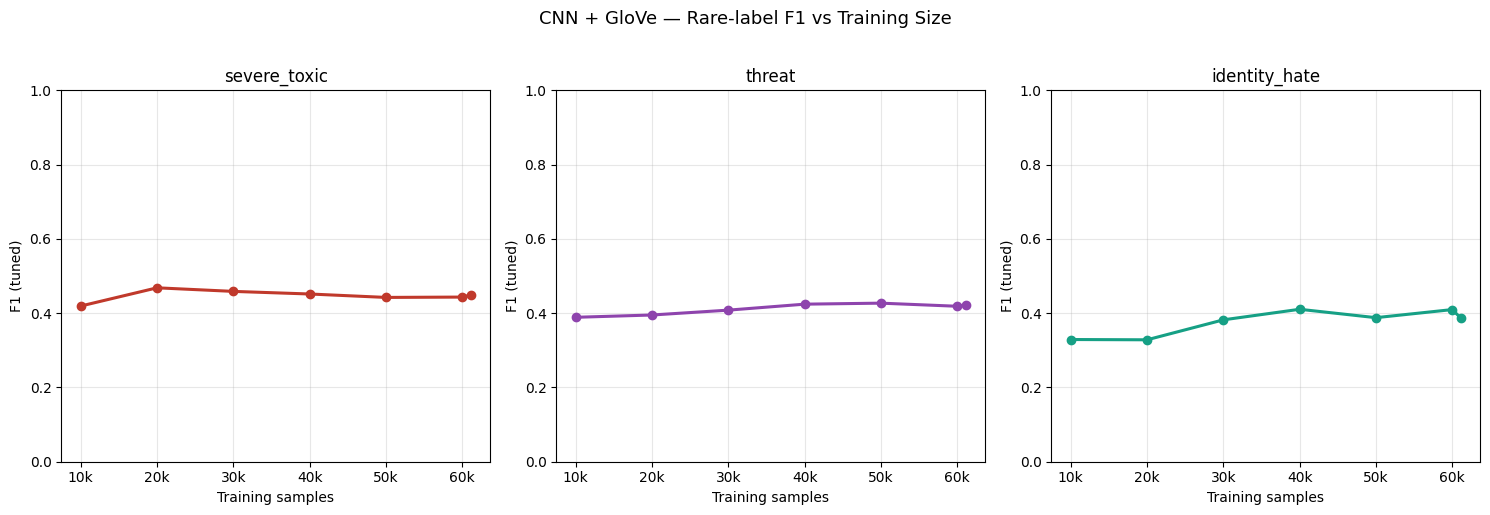

In [16]:
# Graph 4: Rare-label F1 focus (threat, severe_toxic, identity_hate)
if not per_label_all.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
    for ax, label in zip(axes, RARE_LABELS):
        ldf = per_label_all[per_label_all['label'] == label].sort_values('train_size')
        ax.plot(ldf['train_size'], ldf['f1'],
                marker='o', color=LABEL_COLORS[label], linewidth=2.2, label=label)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
        ax.set_xlabel('Training samples', fontsize=10)
        ax.set_ylabel('F1 (tuned)', fontsize=10)
        ax.set_title(label, fontsize=12)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
    plt.suptitle('CNN + GloVe — Rare-label F1 vs Training Size', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / 'graph4_rare_label_f1.png', dpi=150, bbox_inches='tight')
    plt.show()


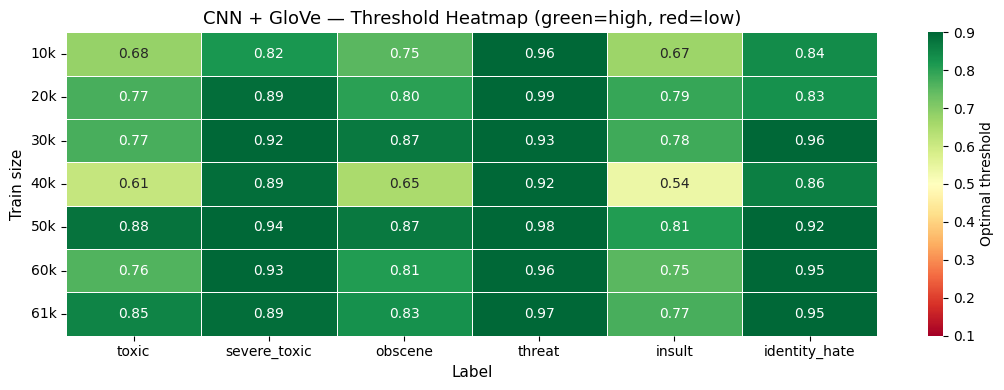

In [17]:
# Graph 5: Decision-threshold heatmap
# Low threshold = model under-predicts at t=0.5. Stable rows = well-calibrated probabilities.
if not thresholds_all.empty:
    sizes_sorted = sorted(thresholds_all['train_size'].unique())
    labels_order = list(LABEL_COLUMNS)
    heatmap_data = pd.DataFrame(index=sizes_sorted, columns=labels_order, dtype=float)
    for sz in sizes_sorted:
        sub = thresholds_all[thresholds_all['train_size'] == sz].set_index('label')
        for lbl in labels_order:
            if lbl in sub.index:
                heatmap_data.loc[sz, lbl] = float(sub.loc[lbl, 'best_threshold'])

    fig, ax = plt.subplots(figsize=(11, max(4, len(sizes_sorted) * 0.55)))
    sns.heatmap(
        heatmap_data.astype(float), annot=True, fmt='.2f',
        cmap='RdYlGn', vmin=0.1, vmax=0.9, linewidths=0.4,
        ax=ax, cbar_kws={'label': 'Optimal threshold'}
    )
    ax.set_xlabel('Label', fontsize=11)
    ax.set_ylabel('Train size', fontsize=11)
    ax.set_title('CNN + GloVe — Threshold Heatmap (green=high, red=low)', fontsize=13)
    ax.set_yticklabels([f'{int(s)/1000:.0f}k' for s in sizes_sorted], rotation=0)
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / 'graph5_threshold_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


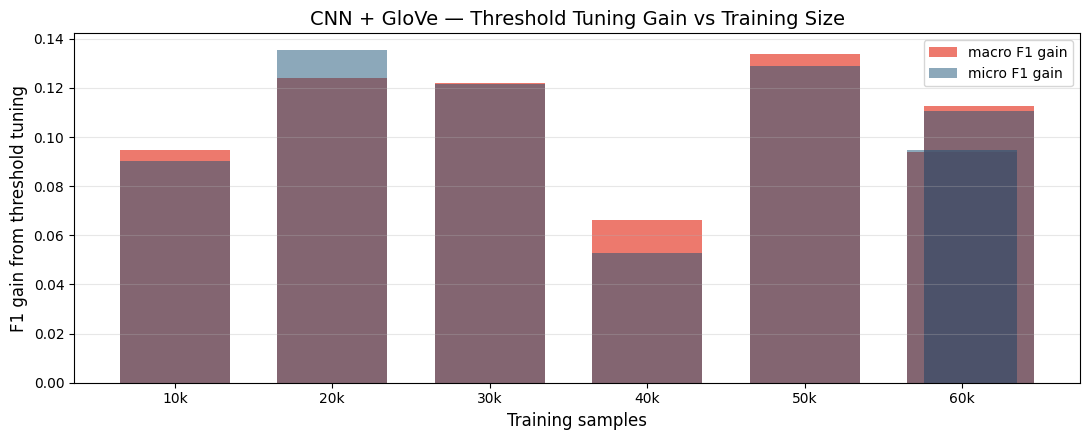

In [18]:
# Graph 6: Threshold tuning gain (tuned - baseline F1)
# Large gain = model miscalibrated at t=0.5; typically high on rare labels.
plot_df = summary_df.sort_values('train_size').copy()
plot_df['gain_macro'] = plot_df['tuned_macro_f1'] - plot_df['baseline_macro_f1']
plot_df['gain_micro'] = plot_df['tuned_micro_f1'] - plot_df['baseline_micro_f1']

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(plot_df['train_size'], plot_df['gain_macro'], width=SIZE_STEP * 0.7,
       color='#e74c3c', alpha=0.75, label='macro F1 gain')
ax.bar(plot_df['train_size'], plot_df['gain_micro'], width=SIZE_STEP * 0.7,
       color='#1a5276', alpha=0.5, label='micro F1 gain')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_xlabel('Training samples', fontsize=12)
ax.set_ylabel('F1 gain from threshold tuning', fontsize=12)
ax.set_title('CNN + GloVe — Threshold Tuning Gain vs Training Size', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'graph6_tuning_gain.png', dpi=150, bbox_inches='tight')
plt.show()


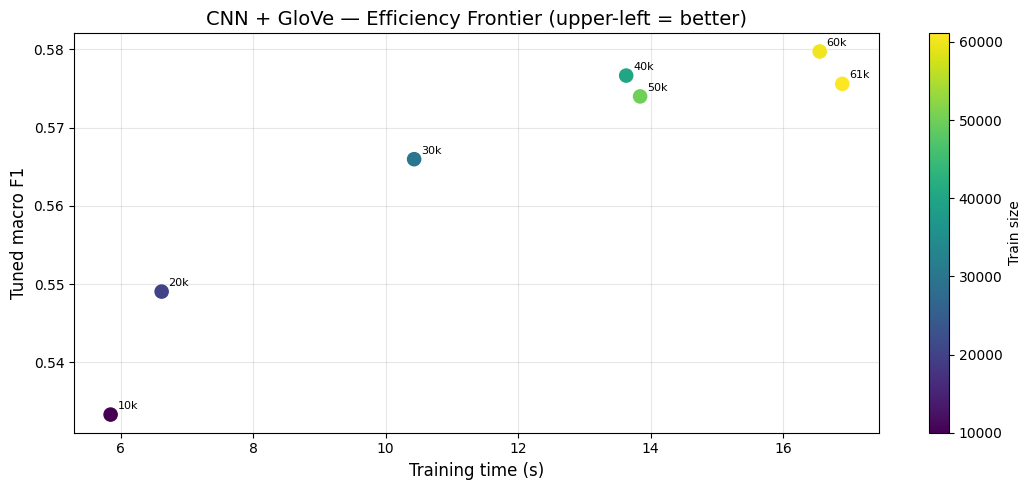

In [19]:
# Graph 7: Efficiency frontier — macro F1 vs training time
# Each point is one training-size run; colour encodes dataset size.
# Upper-left = better efficiency (higher F1, shorter training time).
plot_df = summary_df.sort_values('train_size').copy()

fig, ax = plt.subplots(figsize=(11, 5))
sc = ax.scatter(
    plot_df['train_time_s'], plot_df['tuned_macro_f1'],
    c=plot_df['train_size'], cmap='viridis', s=90, zorder=3
)
for _, r in plot_df.iterrows():
    ax.annotate(
        f"{int(r['train_size'])/1000:.0f}k",
        (r['train_time_s'], r['tuned_macro_f1']),
        textcoords='offset points', xytext=(5, 4), fontsize=8
    )
plt.colorbar(sc, ax=ax, label='Train size')
ax.set_xlabel('Training time (s)', fontsize=12)
ax.set_ylabel('Tuned macro F1', fontsize=12)
ax.set_title('CNN + GloVe — Efficiency Frontier (upper-left = better)', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'graph7_efficiency_frontier.png', dpi=150, bbox_inches='tight')
plt.show()


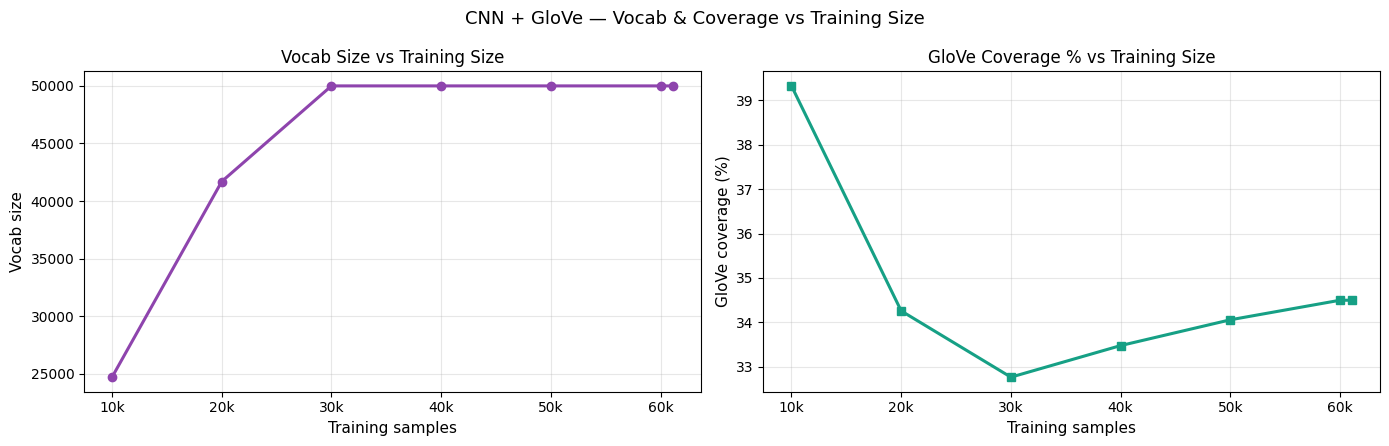

In [20]:
# Graph 8: GloVe coverage and vocab size vs training size
# Unique to word-embedding models — shows how vocabulary and coverage evolve with dataset size.
plot_df = summary_df.sort_values('train_size').copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.plot(plot_df['train_size'], plot_df['vocab_size'],
         marker='o', color='#8e44ad', linewidth=2.2)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax1.set_xlabel('Training samples', fontsize=11)
ax1.set_ylabel('Vocab size', fontsize=11)
ax1.set_title('Vocab Size vs Training Size', fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.plot(plot_df['train_size'], plot_df['glove_coverage_pct'],
         marker='s', color='#16a085', linewidth=2.2)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax2.set_xlabel('Training samples', fontsize=11)
ax2.set_ylabel('GloVe coverage (%)', fontsize=11)
ax2.set_title('GloVe Coverage % vs Training Size', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.suptitle('CNN + GloVe — Vocab & Coverage vs Training Size', fontsize=13)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'graph8_vocab_coverage.png', dpi=150, bbox_inches='tight')
plt.show()


In [21]:
import IPython.display as ipd

key_cols = [
    'train_size', 'actual_train_samples', 'vocab_size', 'glove_coverage_pct',
    'epochs_ran', 'best_epoch', 'early_stopped',
    'baseline_micro_f1', 'baseline_macro_f1',
    'tuned_micro_f1',    'tuned_macro_f1',
    'train_time_s',      'inference_time_s',
]

print('=== CNN + GloVe Training-Size Sweep Summary ===')
ipd.display(summary_df[key_cols])

print('\n=== Best run by tuned macro F1 ===')
best_row = summary_df.loc[summary_df['tuned_macro_f1'].idxmax()]
for c in key_cols:
    print(f'  {c}: {best_row[c]}')


=== CNN + GloVe Training-Size Sweep Summary ===


,train_size,actual_train_samples,vocab_size,glove_coverage_pct,epochs_ran,best_epoch,early_stopped,baseline_micro_f1,baseline_macro_f1,tuned_micro_f1,tuned_macro_f1,train_time_s,inference_time_s
0,10000,10000,24700,39.32,7,5,True,0.560384,0.438679,0.650538,0.533322,5.85,0.2671
1,20000,20000,41695,34.26,5,3,True,0.531201,0.424880,0.666667,0.549035,6.62,0.2558
2,30000,30000,50000,32.77,5,3,True,0.564185,0.444029,0.685914,0.565954,10.43,0.2559
3,40000,40000,50000,33.48,5,3,True,0.644770,0.510301,0.697456,0.576634,13.63,0.2552
4,50000,50000,50000,34.06,4,2,True,0.562722,0.440264,0.691460,0.573972,13.84,0.2592
5,60000,60000,50000,34.50,4,2,True,0.611363,0.485706,0.706171,0.579713,16.55,0.2609
6,61088,61088,50000,34.50,4,2,True,0.585096,0.462898,0.695702,0.575577,16.89,0.2580



=== Best run by tuned macro F1 ===
  train_size: 60000
  actual_train_samples: 60000
  vocab_size: 50000
  glove_coverage_pct: 34.5
  epochs_ran: 4
  best_epoch: 2
  early_stopped: True
  baseline_micro_f1: 0.6113629176768209
  baseline_macro_f1: 0.48570639898114587
  tuned_micro_f1: 0.706171412053765
  tuned_macro_f1: 0.5797132586287818
  train_time_s: 16.55
  inference_time_s: 0.2609
